# Experiment 4 — Is large-`N` recovery limited by primitive exposure?

The completed five-seed sweep in Experiment 3 held the total SAE training budget fixed at
`T = 128M` examples. Because every example contains one uniformly selected `x`
primitive and one uniformly selected `y` primitive, the expected number of
training examples containing each named primitive is

$$K = \frac{T}{N}. $$

The nearly perfect `N=8` condition had `K = 128M / 8 = 16M`, whereas the
declining `N=256` condition had only `K = 128M / 256 = 0.5M`. This notebook
holds `N=256` fixed and increases `K`. The primary test gives `N=256` the same
`K=16M` exposure as `N=8`, requiring `T=4.096B` generated examples. Higher
values `K=24M` and `K=32M` test whether still more training restores true-feature recovery.


## What this experiment can establish

- If `N=256` recovery approaches the `N=8` reference at `K=16M`, the original
  decline was substantially caused by insufficient training exposure per primitive.
- If recovery improves only above `K=16M`, larger SAEs require more exposure per
  primitive than the small successful model.
- If recovery plateaus well below the reference even at larger `K`, additional
  training budget alone does not explain the large-`N` decline.

**Scope limitation:** increasing `K` increases both fresh generated samples and
optimizer steps. It therefore tests total training exposure, not unique-data budget
and optimization steps separately. A later control would compare fresh samples
against repeated passes over a fixed activation buffer at the same step count.

Matching `K` also does not match exposure per composed pair. Under independent
uniform sampling, an individual pair occurs `T/N² = K/N` times on average. At
`K=16M`, this is 2M occurrences per pair for `N=8` but only 62,500 for `N=256`.


## Environment setup (local or Google Colab)

Run the next cell before any imports. Locally, it finds the existing checkout and performs no clone, pull, or package installation. In Google Colab, it uses `/content/SAE`, clones the GitHub repository when absent, safely fast-forwards a clean existing clone when enabled, and installs `requirements.txt`. Google Drive is never mounted.

Checkpoints, CSV results, and PNG plots always live beneath the checkout's `composed-features/artifacts` directory. A Colab clone includes results and plots committed to the repository, but `/content` is runtime-local: download, commit, or otherwise copy newly generated artifacts before resetting the Colab runtime if they must survive the session.


In [1]:
from __future__ import annotations

import importlib.util
import os
import subprocess
import sys
from pathlib import Path


IN_COLAB = importlib.util.find_spec('google.colab') is not None
INSTALL_REQUIREMENTS = IN_COLAB
UPDATE_EXISTING_COLAB_REPOSITORY = True
COLAB_REPOSITORY_URL = 'https://github.com/Adefioye/SAE.git'
COLAB_REPOSITORY_ROOT = Path('/content/SAE')


def find_experiment_dir(start: Path) -> Path | None:
    candidates = (start, start / 'composed-features')
    return next(
        (path for path in candidates
         if (path / 'sparse_factorial_generator.py').is_file()),
        None,
    )


if IN_COLAB:
    repository_root = COLAB_REPOSITORY_ROOT
    EXPERIMENT_DIR = find_experiment_dir(repository_root)
    if EXPERIMENT_DIR is None:
        if repository_root.exists() and any(repository_root.iterdir()):
            raise FileExistsError(
                f'{repository_root} exists but is not the SAE repository. '
                'Choose another path or move that directory.'
            )
        repository_root.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            [
                'git', 'clone', '--depth', '1',
                COLAB_REPOSITORY_URL, str(repository_root),
            ],
            check=True,
        )
    elif UPDATE_EXISTING_COLAB_REPOSITORY:
        git_directory = repository_root / '.git'
        if git_directory.is_dir():
            repository_status = subprocess.run(
                ['git', '-C', str(repository_root), 'status', '--porcelain'],
                check=True, capture_output=True, text=True,
            ).stdout.strip()
            if repository_status:
                print('Existing Colab clone has local changes; skipping pull.')
            else:
                subprocess.run(
                    ['git', '-C', str(repository_root), 'pull', '--ff-only'],
                    check=True,
                )
        else:
            print('Existing project is not a Git clone; skipping pull.')
    EXPERIMENT_DIR = find_experiment_dir(repository_root)
else:
    EXPERIMENT_DIR = find_experiment_dir(Path.cwd().resolve())

if EXPERIMENT_DIR is None:
    raise FileNotFoundError(
        'Could not find composed-features/sparse_factorial_generator.py. '
        'Run locally from the repository root/composed-features directory, '
        'or verify the Colab repository URL.'
    )

EXPERIMENT_DIR = EXPERIMENT_DIR.resolve()
REQUIREMENTS_PATH = EXPERIMENT_DIR / 'requirements.txt'
if not REQUIREMENTS_PATH.is_file():
    raise FileNotFoundError(f'Missing requirements file: {REQUIREMENTS_PATH}')

if INSTALL_REQUIREMENTS:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        '--upgrade-strategy', 'only-if-needed',
        '-r', str(REQUIREMENTS_PATH),
    ])

os.chdir(EXPERIMENT_DIR)
print('Runtime:', 'Google Colab' if IN_COLAB else 'local Jupyter')
print('Experiment directory:', EXPERIMENT_DIR)
print('Requirements installed:', INSTALL_REQUIREMENTS)
if IN_COLAB:
    print('Colab storage: runtime-local (Google Drive is not used)')


Runtime: local Jupyter
Experiment directory: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features
Requirements installed: False


In [2]:
import json
import sys
from collections.abc import Iterator, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Image, display
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm


if 'EXPERIMENT_DIR' not in globals():
    WORKING_DIR = Path.cwd().resolve()
    if (WORKING_DIR / 'sparse_factorial_generator.py').is_file():
        EXPERIMENT_DIR = WORKING_DIR
    elif (WORKING_DIR / 'composed-features' / 'sparse_factorial_generator.py').is_file():
        EXPERIMENT_DIR = WORKING_DIR / 'composed-features'
    else:
        raise FileNotFoundError(
            'Run the Environment setup cell before this import cell.'
        )
EXPERIMENT_DIR = Path(EXPERIMENT_DIR).resolve()

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sparse_factorial_generator import FactorialConfig, SparseFactorialGenerator
from toy_model import default_device


DEVICE = default_device()
ARTIFACT_ROOT = EXPERIMENT_DIR / 'artifacts' / '04_fixed_primitive_exposure'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'sae_trajectories'
RESULTS_ROOT = ARTIFACT_ROOT / 'results'
REFERENCE_PATH = (
    EXPERIMENT_DIR
    / 'artifacts'
    / '03_sparse_factorial_antipodal'
    / 'results'
    / 'n_primitive_recovery_128m_5_sae_seeds_aggregate.csv'
)
for path in (CHECKPOINT_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)


def load_n8_reference() -> pd.Series:
    if REFERENCE_PATH.is_file():
        reference_frame = pd.read_csv(REFERENCE_PATH)
        matches = reference_frame.loc[reference_frame['n_per_set'] == 8]
        if len(matches) != 1:
            raise ValueError(
                f'Expected exactly one N=8 row in {REFERENCE_PATH}.'
            )
        return matches.iloc[0]

    print(
        'Experiment 3 reference CSV is absent; using the recorded N=8 '
        'five-seed means embedded in this notebook.'
    )
    return pd.Series({
        'n_per_set': 8,
        'n_sae_seeds': 5,
        'hungarian_90_mean': 0.9625,
        'mmcs_mean': 0.9916242003440857,
    })


print('Experiment directory:', EXPERIMENT_DIR)
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('CUDA device:', torch.cuda.get_device_name(DEVICE))
elif DEVICE.type == 'mps':
    print('Apple Metal acceleration enabled.')
print('Artifact root:', ARTIFACT_ROOT)
print('Checkpoint root:', CHECKPOINT_ROOT)
print('Results root:', RESULTS_ROOT)


Experiment directory: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features
Device: mps
Apple Metal acceleration enabled.
Artifact root: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure
Checkpoint root: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/sae_trajectories
Results root: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results


## Experimental constants and exposure milestones

The full experiment keeps the Experiment 3 setup fixed: `N=256`, activation
dimension 256, 512 SAE latents, uniform independent feature identities, perfectly
correlated pair amplitudes, no singleton examples, and SAE seed 0. Experiment 3
showed very small seed-to-seed variance at `N=256`, so this experiment uses one
trajectory to concentrate compute on substantially larger training budgets.

Milestones are evaluated along one continuous training trajectory. The curve starts
at half the successful `N=8` exposure and reaches twice that exposure. Checkpoints
contain SAE weights, optimizer
state, scheduler state, and generator RNG state, so interrupted runs can resume.
Checkpoint directories are namespaced by training batch size, preventing an
incompatible historical trajectory from being resumed accidentally.


In [3]:
N_PER_SET = 256
ACTIVATION_DIM = 256
D_SAE = 2 * N_PER_SET
TRAIN_BATCH_SIZE = 16_384
LEARNING_RATE = 3e-4
L1_COEFFICIENT = 0.3
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999
DICTIONARY_SEED = 0
DATA_SEED = 0
SAE_SEED = 0
EVAL_SEED = 10_000
EVAL_SAMPLES = 65_536

# K is the expected number of training examples containing each named primitive.
K_VALUES = (8_000_000, 16_000_000, 24_000_000, 32_000_000)

# The full run is extremely expensive. QUICK_MODE only checks the pipeline.
QUICK_MODE = False
QUICK_K_VALUES = (4_000, 8_000)

if QUICK_MODE:
    ACTIVE_K_VALUES = QUICK_K_VALUES
else:
    ACTIVE_K_VALUES = K_VALUES

assert tuple(sorted(set(ACTIVE_K_VALUES))) == ACTIVE_K_VALUES
for k in ACTIVE_K_VALUES:
    assert (k * N_PER_SET) % TRAIN_BATCH_SIZE == 0

print('Quick mode:', QUICK_MODE)
print('SAE seed:', SAE_SEED)
print('K milestones:', ACTIVE_K_VALUES)


Quick mode: False
SAE seed: 0
K milestones: (8000000, 16000000, 24000000, 32000000)


In [4]:
budget_table = pd.DataFrame(
    {
        'K_expected_samples_per_primitive': ACTIVE_K_VALUES,
        'training_samples_T': [k * N_PER_SET for k in ACTIVE_K_VALUES],
        'optimizer_steps': [
            k * N_PER_SET // TRAIN_BATCH_SIZE for k in ACTIVE_K_VALUES
        ],
        'expected_samples_per_pair': [
            k / N_PER_SET for k in ACTIVE_K_VALUES
        ],
        'relative_to_N8_K': [k / 16_000_000 for k in ACTIVE_K_VALUES],
    }
)
display(budget_table.style.format({
    'K_expected_samples_per_primitive': '{:,.0f}',
    'training_samples_T': '{:,.0f}',
    'optimizer_steps': '{:,.0f}',
    'expected_samples_per_pair': '{:,.1f}',
    'relative_to_N8_K': '{:.3g}×',
}))

# Exact full-run mapping for N=256:
# K=8M  -> T=2.048B samples -> 2,000,000 optimizer steps
# K=16M -> T=4.096B samples -> 4,000,000 optimizer steps
# K=24M -> T=6.144B samples -> 6,000,000 optimizer steps
# K=32M -> T=8.192B samples -> 8,000,000 optimizer steps

max_samples_per_seed = max(ACTIVE_K_VALUES) * N_PER_SET
max_steps_per_seed = max_samples_per_seed // TRAIN_BATCH_SIZE
print(f'Maximum samples in the trajectory: {max_samples_per_seed:,}')
print(f'Maximum optimizer steps in the trajectory: {max_steps_per_seed:,}')
print('This is the total for the single SAE trajectory.')


,K_expected_samples_per_primitive,training_samples_T,optimizer_steps,expected_samples_per_pair,relative_to_N8_K
0,"8,000,000","2,048,000,000","125,000","31,250.0",0.5×
1,"16,000,000","4,096,000,000","250,000","62,500.0",1×
2,"24,000,000","6,144,000,000","375,000","93,750.0",1.5×
3,"32,000,000","8,192,000,000","500,000","125,000.0",2×


Maximum samples in the trajectory: 8,192,000,000
Maximum optimizer steps in the trajectory: 500,000
This is the total for the single SAE trajectory.


## Fixed `N=256` antipodal data generator

This reproduces the Experiment 3 `N=256` dictionary exactly for dictionary seed 0.
Each factor set contains 128 antipodal axis pairs. The `x` and `y` axes occupy
orthogonal subspaces before a random orthogonal rotation. Every generated example
contains exactly one uniformly sampled `x` primitive and one uniformly sampled `y`
primitive with a shared amplitude.


In [5]:
def orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device='cpu').manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int,
    *,
    seed: int,
    device: torch.device | str,
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError('Antipodal geometry requires a positive, even N.')

    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0

        y_offset = n_per_set
        y_axis = half + axis
        dictionary[y_offset + 2 * axis, y_axis] = 1.0
        dictionary[y_offset + 2 * axis + 1, y_axis] = -1.0

    return (dictionary @ orthogonal_matrix(n_per_set, seed)).to(device)


TRUE_DICTIONARY = make_antipodal_dictionary(
    N_PER_SET, seed=DICTIONARY_SEED, device=DEVICE
)


def build_generator(seed: int) -> SparseFactorialGenerator:
    return SparseFactorialGenerator(
        FactorialConfig(
            n_x=N_PER_SET,
            n_y=N_PER_SET,
            activation_dim=ACTIVATION_DIM,
            amplitude_correlation=1.0,
            singleton_probability=0.0,
            noise_std=0.0,
            seed=seed,
        ),
        device=str(DEVICE),
        true_dictionary=TRUE_DICTIONARY,
        normalize_dictionary=False,
    )


class SparseFactorialActivationIterator(Iterator[torch.Tensor]):
    def __init__(self, generator: SparseFactorialGenerator, batch_size: int):
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    @torch.no_grad()
    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


unit_dictionary = F.normalize(TRUE_DICTIONARY, dim=1)
x_dictionary = unit_dictionary[:N_PER_SET]
y_dictionary = unit_dictionary[N_PER_SET:]
assert torch.allclose(x_dictionary[0::2], -x_dictionary[1::2], atol=2e-5)
assert torch.allclose(y_dictionary[0::2], -y_dictionary[1::2], atol=2e-5)
assert float((x_dictionary @ y_dictionary.T).abs().max()) < 2e-5
print('Verified fixed N=256 orthogonal-antipodal dictionary.')


Verified fixed N=256 orthogonal-antipodal dictionary.


## SAE and resumable trajectory training

All milestones for a seed belong to one continuous optimizer trajectory. This is a
paired learning-curve experiment: the decoder evaluated at a larger `K` is the same
SAE after additional training, not a new initialization. Different SAE seeds provide
independent trajectories. Checkpoints are loaded onto whichever accelerator is
active (`cuda` in Colab or `mps` on Apple Silicon). Exact continuation of a
saved generator RNG stream should remain on the same accelerator backend; CSV
results and PNG plots are portable across both environments.


In [6]:
def make_standard_sae(sae_seed: int) -> StandardTrainingSAE:
    torch.manual_seed(sae_seed)
    cfg = StandardTrainingSAEConfig(
        d_in=ACTIVATION_DIM,
        d_sae=D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=L1_COEFFICIENT,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(cfg).to(DEVICE)


def make_trainer(
    sae: StandardTrainingSAE,
    generator: SparseFactorialGenerator,
    *,
    total_training_samples: int,
) -> SAETrainer:
    cfg = SAETrainerConfig(
        total_training_samples=total_training_samples,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=LEARNING_RATE,
        lr_end=LEARNING_RATE,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=cfg,
        sae=sae,
        data_provider=SparseFactorialActivationIterator(
            generator, TRAIN_BATCH_SIZE
        ),
    )


def milestone_name(k: int) -> str:
    total = k * N_PER_SET
    return f'K{k:012d}__T{total:015d}'


def seed_checkpoint_root(sae_seed: int) -> Path:
    return (
        CHECKPOINT_ROOT
        / f'N{N_PER_SET:04d}__batch-{TRAIN_BATCH_SIZE:06d}__sae-{sae_seed}'
    )


def legacy_seed_checkpoint_root(sae_seed: int) -> Path:
    return CHECKPOINT_ROOT / f'N{N_PER_SET:04d}__sae-{sae_seed}'


def checkpoint_spec_matches(
    path: Path, *, sae_seed: int, k: int
) -> bool:
    spec_path = path / 'experiment_spec.json'
    if not spec_path.is_file():
        return False
    try:
        spec = json.loads(spec_path.read_text())
    except (OSError, json.JSONDecodeError):
        return False
    expected = {
        'n_per_set': N_PER_SET,
        'activation_dim': ACTIVATION_DIM,
        'd_sae': D_SAE,
        'sae_seed': sae_seed,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'k_expected_samples_per_primitive': k,
        'training_samples': k * N_PER_SET,
        'batch_size': TRAIN_BATCH_SIZE,
        'lr': LEARNING_RATE,
        'l1_coefficient': L1_COEFFICIENT,
    }
    return all(spec.get(key) == value for key, value in expected.items())


def milestone_path(sae_seed: int, k: int) -> Path:
    current_path = seed_checkpoint_root(sae_seed) / milestone_name(k)
    if current_path.exists():
        spec_path = current_path / 'experiment_spec.json'
        if (
            spec_path.is_file()
            and not checkpoint_spec_matches(
                current_path, sae_seed=sae_seed, k=k
            )
        ):
            raise ValueError(
                f'Checkpoint settings do not match this run: {current_path}'
            )
        return current_path

    legacy_path = legacy_seed_checkpoint_root(sae_seed) / milestone_name(k)
    if checkpoint_spec_matches(legacy_path, sae_seed=sae_seed, k=k):
        return legacy_path
    return current_path


def checkpoint_is_resumable(path: Path) -> bool:
    required = (
        'cfg.json',
        'sae_weights.safetensors',
        'trainer_state.pt',
        'activation_scaler.json',
        'generator_rng_state.pt',
        'experiment_spec.json',
    )
    return all((path / name).exists() for name in required)


def save_milestone(
    trainer: SAETrainer,
    generator: SparseFactorialGenerator,
    *,
    sae_seed: int,
    k: int,
) -> Path:
    root = seed_checkpoint_root(sae_seed)
    root.mkdir(parents=True, exist_ok=True)
    name = milestone_name(k)
    trainer.save_checkpoint(checkpoint_name=name, base_path=root)
    path = root / name
    torch.save(generator.rng.get_state(), path / 'generator_rng_state.pt')
    metadata = {
        'n_per_set': N_PER_SET,
        'activation_dim': ACTIVATION_DIM,
        'd_sae': D_SAE,
        'sae_seed': sae_seed,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'k_expected_samples_per_primitive': k,
        'training_samples': k * N_PER_SET,
        'training_steps': trainer.n_training_steps,
        'batch_size': TRAIN_BATCH_SIZE,
        'lr': LEARNING_RATE,
        'l1_coefficient': L1_COEFFICIENT,
        'device_used_to_train': str(DEVICE),
    }
    (path / 'experiment_spec.json').write_text(
        json.dumps(metadata, indent=2) + '\n'
    )
    return path


def load_trainer_state_for_device(
    trainer: SAETrainer, checkpoint: Path
) -> None:
    trainer.activation_scaler.load(checkpoint / 'activation_scaler.json')
    state = torch.load(
        checkpoint / 'trainer_state.pt',
        map_location=DEVICE,
        weights_only=False,
    )
    trainer.optimizer.load_state_dict(state['optimizer'])
    trainer.lr_scheduler.load_state_dict(state['lr_scheduler'])
    trainer.n_training_samples = state['n_training_samples']
    trainer.n_training_steps = state['n_training_steps']
    trainer.act_freq_scores = state['act_freq_scores']
    trainer.n_forward_passes_since_fired = (
        state['n_forward_passes_since_fired']
    )
    trainer.n_frac_active_samples = state['n_frac_active_samples']
    trainer.started_fine_tuning = state['started_fine_tuning']
    for name, scheduler_state in state['coefficient_schedulers'].items():
        trainer.coefficient_schedulers[name].load_state_dict(
            scheduler_state
        )


def initialize_or_resume_trajectory(
    sae_seed: int,
    k_values: Sequence[int],
) -> tuple[SAETrainer, SparseFactorialGenerator, int | None]:
    generator = build_generator(DATA_SEED)
    completed_k = [
        k for k in k_values if checkpoint_is_resumable(milestone_path(sae_seed, k))
    ]
    latest_k = max(completed_k, default=None)
    max_total = max(k_values) * N_PER_SET

    if latest_k is None:
        sae = make_standard_sae(sae_seed)
        trainer = make_trainer(
            sae, generator, total_training_samples=max_total
        )
        return trainer, generator, None

    checkpoint = milestone_path(sae_seed, latest_k)
    sae = StandardTrainingSAE.load_from_disk(
        checkpoint, device=str(DEVICE), dtype='float32'
    ).to(DEVICE)
    trainer = make_trainer(sae, generator, total_training_samples=max_total)
    load_trainer_state_for_device(trainer, checkpoint)
    generator_state = torch.load(
        checkpoint / 'generator_rng_state.pt',
        map_location='cpu',
        weights_only=True,
    )
    generator.rng.set_state(generator_state)
    expected_samples = latest_k * N_PER_SET
    if trainer.n_training_samples != expected_samples:
        raise ValueError(
            f'Resumed {trainer.n_training_samples:,} samples; '
            f'expected {expected_samples:,}.'
        )
    return trainer, generator, latest_k


def ensure_seed_trajectory(sae_seed: int, k_values: Sequence[int]) -> None:
    trainer, generator, latest_k = initialize_or_resume_trajectory(
        sae_seed, k_values
    )
    pending = [k for k in k_values if latest_k is None or k > latest_k]
    if not pending:
        print(f'SAE seed {sae_seed}: all milestones already complete.')
        return

    pbar = tqdm(
        total=max(k_values) * N_PER_SET,
        initial=trainer.n_training_samples,
        desc=f'SAE seed {sae_seed}',
    )
    for k in pending:
        target_samples = k * N_PER_SET
        while trainer.n_training_samples < target_samples:
            trainer.maybe_reset_sparsity()
            trainer.step(next(trainer.data_provider))
            trainer.n_training_steps += 1
            pbar.update(TRAIN_BATCH_SIZE)
        if trainer.n_training_samples != target_samples:
            raise RuntimeError('A K milestone was not batch-aligned.')
        path = save_milestone(
            trainer, generator, sae_seed=sae_seed, k=k
        )
        print(f'\nSaved K={k:,}: {path}')
    pbar.close()

    del trainer
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


## Recovery and training-quality metrics

The primary outcomes match Experiment 3: one-to-one Hungarian primitive recovery
at cosine 0.90 and MMCS. The notebook also records evaluation FVU, mean SAE `L0`,
and the fraction of latents that never activate on
the fresh evaluation batch. High reconstruction quality with persistently poor
primitive recovery would indicate an alternative learned dictionary rather than
simple failure to fit the activation distribution.


In [7]:
@torch.no_grad()
def primitive_recovery_metrics(
    sae: StandardTrainingSAE, dictionary: torch.Tensor
) -> dict[str, float]:
    decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitives = F.normalize(dictionary.detach().float(), dim=1)
    similarity = primitives @ decoder.T

    mmcs = float(similarity.max(dim=1).values.mean())
    primitive_rows, decoder_cols = linear_sum_assignment(
        -similarity.detach().cpu().numpy()
    )
    assigned = similarity[
        torch.as_tensor(primitive_rows, device=similarity.device),
        torch.as_tensor(decoder_cols, device=similarity.device),
    ]
    return {
        'hungarian_90': float((assigned >= 0.90).float().mean()),
        'mmcs': mmcs,
        'hungarian_assigned_cosine_mean': float(assigned.mean()),
        'hungarian_assigned_cosine_min': float(assigned.min()),
    }


@torch.no_grad()
def training_quality_metrics(sae: StandardTrainingSAE) -> dict[str, float]:
    evaluation_generator = build_generator(EVAL_SEED)
    hidden, _ = evaluation_generator.sample(EVAL_SAMPLES)
    feature_acts = sae.encode(hidden)
    reconstructed = sae.decode(feature_acts)

    squared_error = (hidden - reconstructed).pow(2).sum()
    total_variance = (hidden - hidden.mean(dim=0)).pow(2).sum()
    fired = feature_acts > 0
    return {
        'eval_fvu': float(squared_error / total_variance),
        'eval_mean_l0': float(fired.sum(dim=1).float().mean()),
        'eval_mean_l1': float(feature_acts.abs().sum(dim=1).mean()),
        'eval_dead_latent_fraction': float((~fired.any(dim=0)).float().mean()),
    }


RESULT_COLUMNS = [
    'n_per_set',
    'sae_seed',
    'dictionary_seed',
    'data_seed',
    'train_batch_size',
    'k_expected_samples_per_primitive',
    'training_samples',
    'optimizer_steps',
    'expected_samples_per_pair',
    'hungarian_90',
    'mmcs',
    'hungarian_assigned_cosine_mean',
    'hungarian_assigned_cosine_min',
    'eval_fvu',
    'eval_mean_l0',
    'eval_mean_l1',
    'eval_dead_latent_fraction',
]


def evaluate_saved_milestones(
    sae_seeds: Sequence[int],
    k_values: Sequence[int],
    output_path: Path,
) -> pd.DataFrame:
    rows = []
    for sae_seed in sae_seeds:
        for k in k_values:
            checkpoint = milestone_path(sae_seed, k)
            if not checkpoint_is_resumable(checkpoint):
                raise FileNotFoundError(f'Incomplete checkpoint: {checkpoint}')
            sae = StandardTrainingSAE.load_from_disk(
                checkpoint, device=str(DEVICE), dtype='float32'
            ).to(DEVICE)
            row = {
                'n_per_set': N_PER_SET,
                'sae_seed': sae_seed,
                'dictionary_seed': DICTIONARY_SEED,
                'data_seed': DATA_SEED,
                'train_batch_size': TRAIN_BATCH_SIZE,
                'k_expected_samples_per_primitive': k,
                'training_samples': k * N_PER_SET,
                'optimizer_steps': k * N_PER_SET // TRAIN_BATCH_SIZE,
                'expected_samples_per_pair': k / N_PER_SET,
                **primitive_recovery_metrics(sae, TRUE_DICTIONARY),
                **training_quality_metrics(sae),
            }
            rows.append(row)
            pd.DataFrame(rows)[RESULT_COLUMNS].to_csv(output_path, index=False)
            print(
                f'Evaluated seed={sae_seed}, K={k:,}: '
                f'H90={row["hungarian_90"]:.4f}, MMCS={row["mmcs"]:.4f}'
            )
            del sae
            if DEVICE.type == 'mps':
                torch.mps.empty_cache()
            elif DEVICE.type == 'cuda':
                torch.cuda.empty_cache()

    return (
        pd.DataFrame(rows)[RESULT_COLUMNS]
        .sort_values(['k_expected_samples_per_primitive', 'sae_seed'])
        .reset_index(drop=True)
    )


def load_results_table(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    if 'train_batch_size' not in frame.columns:
        inferred = frame['training_samples'] / frame['optimizer_steps']
        if not (inferred == inferred.astype('int64')).all():
            raise ValueError(f'Cannot infer the saved batch size from {path}.')
        frame.insert(
            frame.columns.get_loc('data_seed') + 1,
            'train_batch_size',
            inferred.astype('int64'),
        )
    missing = set(RESULT_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f'{path} is missing result columns: {sorted(missing)}')
    saved_batch_sizes = sorted(frame['train_batch_size'].unique())
    print('Loaded', path)
    print('Saved training batch size(s):', saved_batch_sizes)
    if saved_batch_sizes != [TRAIN_BATCH_SIZE]:
        print(
            'This is a historical result table. It will be displayed but not '
            'used as a checkpoint for the current batch-size configuration.'
        )
    return frame


## Run the experiment

Set `RUN_EXPERIMENT=True` deliberately. For a pipeline check, first set
`QUICK_MODE=True` and rerun the configuration cell. For the full experiment,
`QUICK_MODE=False` requires 8.192B samples and 500K optimizer steps at batch 16,384 for the single
SAE seed. Because milestones share one continuous trajectory, those values
are totals, not costs that must be added together. With the run flag disabled,
the notebook first loads batch-matched results and then falls back to the existing
historical CSV/PNG pair without treating it as a resumable checkpoint.


In [8]:
RUN_EXPERIMENT = False

run_label = 'quick' if QUICK_MODE else 'full_K8m_to_K32m'
artifact_stem = f'fixed_exposure_{run_label}_batch{TRAIN_BATCH_SIZE}'
results_path = RESULTS_ROOT / f'{artifact_stem}.csv'
RECOVERY_PLOT_PATH = RESULTS_ROOT / f'{artifact_stem}_recovery_curves.png'

# These predate batch-size namespacing and remain readable historical artifacts.
legacy_artifact_stem = f'fixed_exposure_{run_label}'
legacy_results_path = RESULTS_ROOT / f'{legacy_artifact_stem}.csv'
LEGACY_RECOVERY_PLOT_PATH = (
    RESULTS_ROOT / f'{legacy_artifact_stem}_recovery_curves.png'
)

if RUN_EXPERIMENT:
    print(f'Running one continuous trajectory with SAE seed {SAE_SEED}.')
    ensure_seed_trajectory(SAE_SEED, ACTIVE_K_VALUES)
    results = evaluate_saved_milestones(
        (SAE_SEED,), ACTIVE_K_VALUES, results_path
    )
    results_loaded_from_disk = False
    active_recovery_plot_path = RECOVERY_PLOT_PATH
elif results_path.is_file():
    results = load_results_table(results_path)
    results_loaded_from_disk = True
    active_recovery_plot_path = RECOVERY_PLOT_PATH
elif legacy_results_path.is_file():
    results = load_results_table(legacy_results_path)
    results_loaded_from_disk = True
    active_recovery_plot_path = LEGACY_RECOVERY_PLOT_PATH
else:
    results = None
    results_loaded_from_disk = False
    active_recovery_plot_path = (
        RECOVERY_PLOT_PATH
        if RECOVERY_PLOT_PATH.is_file()
        else LEGACY_RECOVERY_PLOT_PATH
    )
    print(
        'No saved results yet. Set RUN_EXPERIMENT=True after reviewing the '
        'budget table.'
    )

if results is not None:
    display(results)


Loaded /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_full_K8m_to_K32m.csv
Saved training batch size(s): [np.int64(1024)]
This is a historical result table. It will be displayed but not used as a checkpoint for the current batch-size configuration.


,n_per_set,sae_seed,dictionary_seed,data_seed,train_batch_size,k_expected_samples_per_primitive,training_samples,optimizer_steps,expected_samples_per_pair,hungarian_90,mmcs,hungarian_assigned_cosine_mean,hungarian_assigned_cosine_min,eval_fvu,eval_mean_l0,eval_mean_l1,eval_dead_latent_fraction
0,256,0,0,0,1024,8000000,2048000000,2000000,31250.0,0.896484,0.906997,0.902968,-0.005547,0.150871,1.558441,0.176510,0.091797
1,256,0,0,0,1024,16000000,4096000000,4000000,62500.0,0.896484,0.907029,0.903057,-0.004398,0.151201,1.545349,0.173918,0.099609
2,256,0,0,0,1024,24000000,6144000000,6000000,93750.0,0.896484,0.907026,0.903107,-0.004923,0.151044,1.545731,0.174011,0.099609
3,256,0,0,0,1024,32000000,8192000000,8000000,125000.0,0.896484,0.907042,0.903103,-0.004923,0.150824,1.545898,0.174135,0.099609


## Compact single-trajectory results

There is no cross-seed aggregation or confidence interval. This table retains the
four requested exposure milestones, their exact total sample budgets, Hungarian
recovery at the 0.90 cutoff, MMCS, and the training-quality diagnostics.


In [9]:
if results is not None:
    result_summary = results[[
        'k_expected_samples_per_primitive',
        'training_samples',
        'optimizer_steps',
        'hungarian_90',
        'mmcs',
        'eval_fvu',
        'eval_mean_l0',
        'eval_dead_latent_fraction',
    ]].sort_values('k_expected_samples_per_primitive')
    display(result_summary.style.format({
        'k_expected_samples_per_primitive': '{:,.0f}',
        'training_samples': '{:,.0f}',
        'optimizer_steps': '{:,.0f}',
        'hungarian_90': '{:.4f}',
        'mmcs': '{:.4f}',
        'eval_fvu': '{:.6f}',
        'eval_mean_l0': '{:.3f}',
        'eval_dead_latent_fraction': '{:.4f}',
    }))
else:
    result_summary = None


,k_expected_samples_per_primitive,training_samples,optimizer_steps,hungarian_90,mmcs,eval_fvu,eval_mean_l0,eval_dead_latent_fraction
0,"8,000,000","2,048,000,000","2,000,000",0.8965,0.9070,0.150871,1.558,0.0918
1,"16,000,000","4,096,000,000","4,000,000",0.8965,0.9070,0.151201,1.545,0.0996
2,"24,000,000","6,144,000,000","6,000,000",0.8965,0.9070,0.151044,1.546,0.0996
3,"32,000,000","8,192,000,000","8,000,000",0.8965,0.9070,0.150824,1.546,0.0996


## Recovery learning curves and `N=8` reference

The dashed reference lines show the completed Experiment 3 five-seed mean for the
`N=8`, `T=128M`, `K=16M` condition. The solid line is the single `N=256`, seed-0
training trajectory evaluated at the four requested exposure milestones.


N=8 reference: H90=0.9625, MMCS=0.9916
Loaded /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_full_K8m_to_K32m_recovery_curves.png


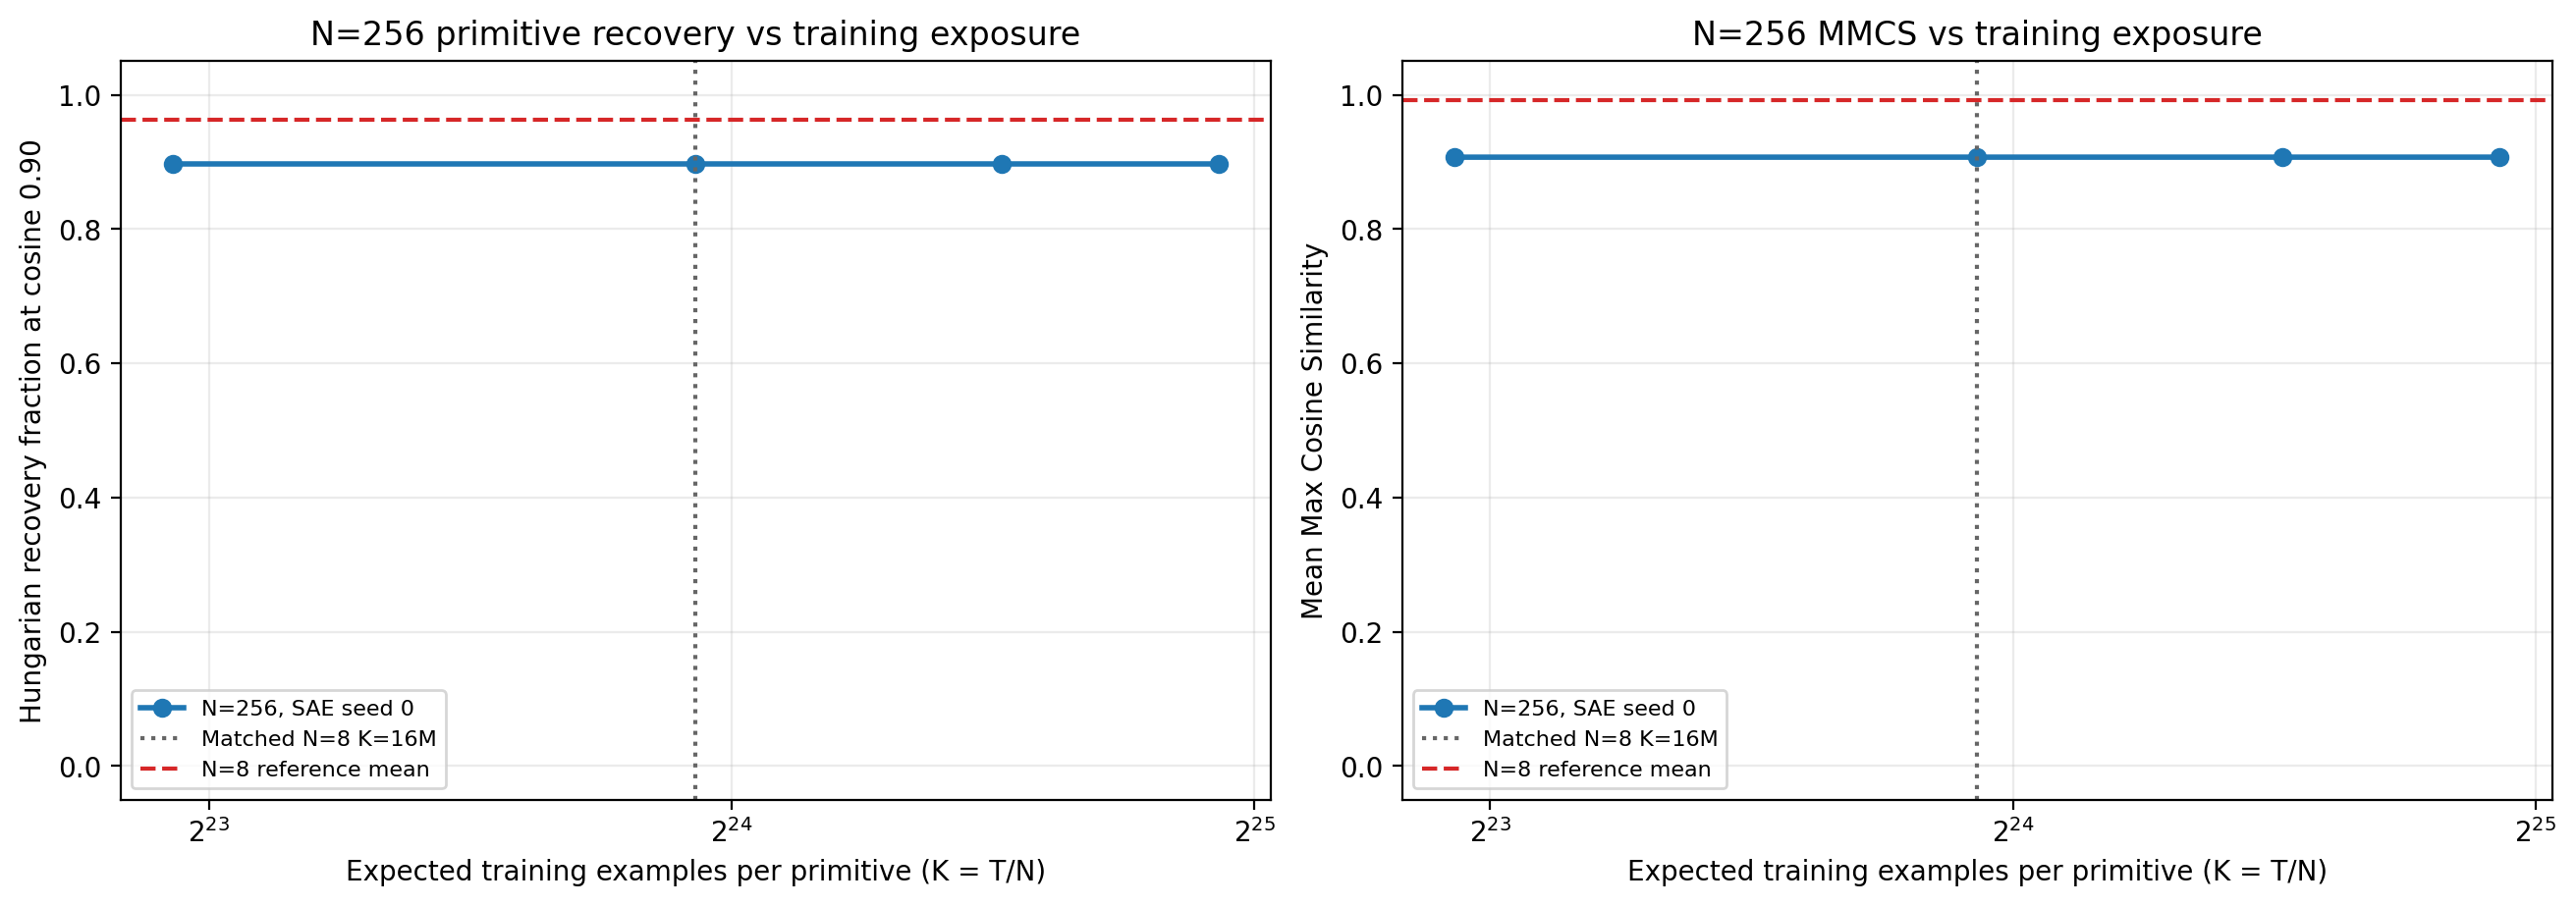

In [10]:
n8_reference = load_n8_reference()
print(
    'N=8 reference:',
    f'H90={n8_reference["hungarian_90_mean"]:.4f},',
    f'MMCS={n8_reference["mmcs_mean"]:.4f}',
)


def plot_learning_curve(
    ax,
    frame: pd.DataFrame,
    *,
    metric: str,
    title: str,
    ylabel: str,
    reference_mean: float,
) -> None:
    ordered = frame.sort_values('k_expected_samples_per_primitive')
    ax.plot(
        ordered['k_expected_samples_per_primitive'],
        ordered[metric],
        marker='o',
        linewidth=2,
        label='N=256, SAE seed 0',
    )
    ax.axvline(
        16_000_000, color='0.4', linestyle=':', label='Matched N=8 K=16M'
    )
    ax.axhline(
        reference_mean, color='C3', linestyle='--', label='N=8 reference mean'
    )
    ax.set_xscale('log', base=2)
    ax.set(
        title=title,
        xlabel='Expected training examples per primitive (K = T/N)',
        ylabel=ylabel,
        ylim=(-0.05, 1.05),
    )
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)


if (
    results is not None
    and not (
        results_loaded_from_disk and active_recovery_plot_path.is_file()
    )
):
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    plot_learning_curve(
        axes[0],
        results,
        metric='hungarian_90',
        title='N=256 primitive recovery vs training exposure',
        ylabel='Hungarian recovery fraction at cosine 0.90',
        reference_mean=float(n8_reference['hungarian_90_mean']),
    )
    plot_learning_curve(
        axes[1],
        results,
        metric='mmcs',
        title='N=256 MMCS vs training exposure',
        ylabel='Mean Max Cosine Similarity',
        reference_mean=float(n8_reference['mmcs_mean']),
    )
    figure.savefig(
        active_recovery_plot_path, dpi=200, bbox_inches='tight'
    )
    print('Saved', active_recovery_plot_path)
    plt.show()
elif active_recovery_plot_path.is_file():
    print('Loaded', active_recovery_plot_path)
    display(Image(filename=str(active_recovery_plot_path)))


## Interpretation checklist

1. **Lower exposure point:** `K=8M` corresponds to `T=2.048B`, half the successful
   `N=8` exposure per primitive.
2. **Primary matched-exposure test:** compare `N=256, K=16M` (`T=4.096B`) against the five-seed
   `N=8, K=16M` reference (`H90 ≈ 0.963`, `MMCS ≈ 0.992`).
3. **Full recovery:** `hungarian_90 == 1.0` means all 512 primitives have distinct
   decoder matches at cosine at least 0.90.
4. **Beyond matched exposure:** determine whether `K=24M` (`T=6.144B`) and
   `K=32M` (`T=8.192B`) continue improving, plateau, or degrade.
5. **Fit versus representation:** interpret recovery alongside FVU, `L0`, and dead
   latents. Low FVU with low recovery means the SAE fits using a non-ground-truth
   dictionary; high FVU means optimization/training itself remains inadequate.

A restoration of recovery with increasing `K` supports a **training-exposure**
explanation. It should not be described as uniquely proving a data-diversity effect,
because this online generator supplies fresh samples and every increase in `K` also
adds optimizer updates.


# Experiment 4B — Independent SAE initializations at `K=32M`

The learning-curve experiment above used one continuous SAE seed-0 trajectory. Its flat recovery from `K=8M` through `K=32M` suggests an exposure plateau, but one trajectory cannot measure sensitivity to the non-convex SAE initialization.

This follow-up evaluates **three total SAE initialization seeds `(0, 1, 2)`** at the largest exposure, `K=32M` (`T=8.192B`). A completed seed-0 checkpoint is reused only when its saved configuration matches the active batch size; otherwise it is trained as a new trajectory. Dictionary seed, data seed, generated sample order, optimizer, and all SAE hyperparameters remain fixed, isolating SAE initialization as the experimental variable.

Intermediate `K=8M`, `16M`, and `24M` checkpoints are saved only to make pending 8.192B-sample runs resumable. Only the `K=32M` checkpoints enter this comparison.

In [11]:
K32_TARGET_K = 32_000_000
K32_SAE_SEEDS = (0, 1, 2)
K32_RESUME_MILESTONES = tuple(
    K32_TARGET_K * fraction // 4 for fraction in (1, 2, 3, 4)
)
RUN_K32_THREE_SEED_EXPERIMENT = False

K32_ARTIFACT_STEM = (
    f'fixed_exposure_K32m_three_sae_seeds_batch{TRAIN_BATCH_SIZE}'
)
K32_RESULTS_PATH = RESULTS_ROOT / f'{K32_ARTIFACT_STEM}.csv'
K32_SUMMARY_PATH = RESULTS_ROOT / f'{K32_ARTIFACT_STEM}_summary.csv'
K32_PLOT_PATH = RESULTS_ROOT / f'{K32_ARTIFACT_STEM}.png'

assert K32_TARGET_K == K_VALUES[-1]
assert K32_RESUME_MILESTONES[-1] == K32_TARGET_K
for k in K32_RESUME_MILESTONES:
    assert (k * N_PER_SET) % TRAIN_BATCH_SIZE == 0

completed_k32_seeds = [
    seed for seed in K32_SAE_SEEDS
    if checkpoint_is_resumable(milestone_path(seed, K32_TARGET_K))
]
pending_k32_seeds = [
    seed for seed in K32_SAE_SEEDS if seed not in completed_k32_seeds
]
print('K=32M SAE seeds:', K32_SAE_SEEDS)
print('Already complete:', completed_k32_seeds)
print('Pending from-scratch/resume trajectories:', pending_k32_seeds)
print('Samples per complete trajectory:', f'{K32_TARGET_K * N_PER_SET:,}')
print('Resumability milestones:', K32_RESUME_MILESTONES)

K=32M SAE seeds: (0, 1, 2)
Already complete: []
Pending from-scratch/resume trajectories: [0, 1, 2]
Samples per complete trajectory: 8,192,000,000
Resumability milestones: (8000000, 16000000, 24000000, 32000000)


## Train or resume the three `K=32M` trajectories

With matching checkpoint artifacts, completed seeds print that all milestones are complete and pending seeds resume from their latest complete intermediate milestone. The committed CSV/PNG artifacts can be loaded without checkpoints when the run flag is `False`; result files alone are intentionally not treated as resumable optimizer state.

In [12]:
k32_seed_results = None
if RUN_K32_THREE_SEED_EXPERIMENT:
    for sae_seed in K32_SAE_SEEDS:
        ensure_seed_trajectory(sae_seed, K32_RESUME_MILESTONES)
    k32_seed_results = evaluate_saved_milestones(
        K32_SAE_SEEDS, (K32_TARGET_K,), K32_RESULTS_PATH
    )
elif K32_RESULTS_PATH.is_file():
    k32_seed_results = load_results_table(K32_RESULTS_PATH)
else:
    print(
        'Set RUN_K32_THREE_SEED_EXPERIMENT=True to launch the '
        'K=32M trajectories.'
    )

if k32_seed_results is not None:
    display(k32_seed_results.style.format({
        'k_expected_samples_per_primitive': '{:,.0f}',
        'training_samples': '{:,.0f}',
        'optimizer_steps': '{:,.0f}',
        'expected_samples_per_pair': '{:,.1f}',
        'hungarian_90': '{:.4f}',
        'mmcs': '{:.6f}',
        'hungarian_assigned_cosine_mean': '{:.6f}',
        'hungarian_assigned_cosine_min': '{:.6f}',
        'eval_fvu': '{:.6f}',
        'eval_mean_l0': '{:.4f}',
        'eval_mean_l1': '{:.4f}',
        'eval_dead_latent_fraction': '{:.4f}',
    }))

Loaded /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_K32m_three_sae_seeds_batch16384.csv
Saved training batch size(s): [np.int64(16384)]


,n_per_set,sae_seed,dictionary_seed,data_seed,train_batch_size,k_expected_samples_per_primitive,training_samples,optimizer_steps,expected_samples_per_pair,hungarian_90,mmcs,hungarian_assigned_cosine_mean,hungarian_assigned_cosine_min,eval_fvu,eval_mean_l0,eval_mean_l1,eval_dead_latent_fraction
0,256,0,0,0,16384,"32,000,000","8,192,000,000","500,000","125,000.0",0.9043,0.910071,0.905273,-0.005887,0.147913,1.6685,0.2540,0.0273
1,256,1,0,0,16384,"32,000,000","8,192,000,000","500,000","125,000.0",0.8965,0.902304,0.898691,-0.005799,0.153547,1.7010,0.2539,0.0078
2,256,2,0,0,16384,"32,000,000","8,192,000,000","500,000","125,000.0",0.9004,0.911034,0.904024,0.000600,0.144930,1.7015,0.2580,0.0176


## Three-seed aggregation and comparison

The table reports mean, sample standard deviation, minimum, and maximum across the three independent SAE initializations. The plot shows every seed individually, the three-seed mean, and the five-seed `N=8`, `K=16M` reference.

,metric,mean,std,min,max
0,hungarian_90,0.900391,0.003906,0.896484,0.904297
1,mmcs,0.907803,0.004787,0.902304,0.911034
2,hungarian_assigned_cosine_mean,0.902663,0.003496,0.898691,0.905273
3,hungarian_assigned_cosine_min,-0.003695,0.003720,-0.005887,0.000600
4,eval_fvu,0.148797,0.004376,0.144930,0.153547
5,eval_mean_l0,1.690338,0.018951,1.668457,1.701508
6,eval_mean_l1,0.255300,0.002381,0.253884,0.258049
7,eval_dead_latent_fraction,0.017578,0.009766,0.007812,0.027344


Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_K32m_three_sae_seeds_batch16384.csv
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_K32m_three_sae_seeds_batch16384_summary.csv
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_K32m_three_sae_seeds.png


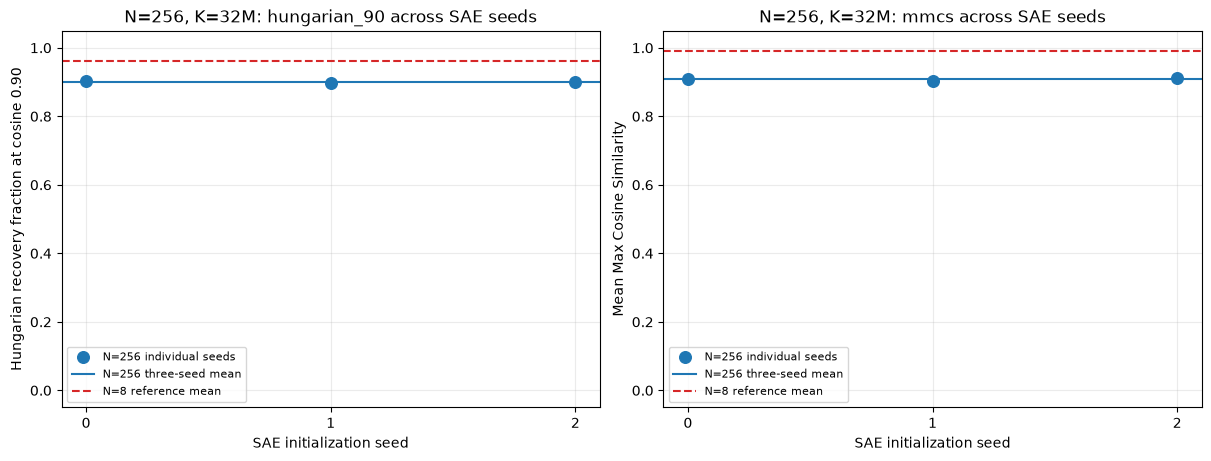

In [13]:
K32_REPORTED_METRICS = [
    'hungarian_90', 'mmcs', 'hungarian_assigned_cosine_mean',
    'hungarian_assigned_cosine_min', 'eval_fvu', 'eval_mean_l0',
    'eval_mean_l1', 'eval_dead_latent_fraction',
]

if k32_seed_results is not None:
    k32_seed_summary = (
        k32_seed_results[K32_REPORTED_METRICS]
        .agg(['mean', 'std', 'min', 'max'])
        .T.reset_index(names='metric')
    )
    k32_seed_summary.to_csv(K32_SUMMARY_PATH, index=False)
    display(k32_seed_summary.style.format({
        'mean': '{:.6f}', 'std': '{:.6f}',
        'min': '{:.6f}', 'max': '{:.6f}',
    }))

    if 'n8_reference' not in globals():
        n8_reference = load_n8_reference()

    figure, axes = plt.subplots(
        1, 2, figsize=(12, 4.5), constrained_layout=True
    )
    plot_specs = (
        ('hungarian_90', 'hungarian_90_mean',
         'Hungarian recovery fraction at cosine 0.90'),
        ('mmcs', 'mmcs_mean', 'Mean Max Cosine Similarity'),
    )
    for ax, (metric, reference_metric, ylabel) in zip(axes, plot_specs):
        values = k32_seed_results.sort_values('sae_seed')
        ax.scatter(
            values['sae_seed'], values[metric],
            s=70, color='C0', label='N=256 individual seeds', zorder=3,
        )
        ax.axhline(
            values[metric].mean(), color='C0', linestyle='-',
            label='N=256 three-seed mean',
        )
        ax.axhline(
            float(n8_reference[reference_metric]),
            color='C3', linestyle='--', label='N=8 reference mean',
        )
        ax.set(
            title=f'N=256, K=32M: {metric} across SAE seeds',
            xlabel='SAE initialization seed', ylabel=ylabel,
            xticks=list(K32_SAE_SEEDS), ylim=(-0.05, 1.05),
        )
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    k32_plot_path = (
        RESULTS_ROOT / 'fixed_exposure_K32m_three_sae_seeds.png'
    )
    figure.savefig(k32_plot_path, dpi=200, bbox_inches='tight')
    print('Saved', K32_RESULTS_PATH)
    print('Saved', K32_SUMMARY_PATH)
    print('Saved', k32_plot_path)
    plt.show()

## Interpretation

- If all three seeds remain near the original seed-0 plateau, the evidence favors an objective or identifiability limitation rather than insufficient exposure or an unlucky initialization.
- If one or more seeds recover substantially better, the plateau is basin-dependent and should be characterized with more initialization seeds.
- These runs intentionally share the same generated sample sequence. They estimate initialization sensitivity, not data-stream sensitivity. Testing data-stream sensitivity would keep the SAE seed fixed and vary `DATA_SEED`.